In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [2]:
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 14 * X**3 + 14 * X**2 + 14 * X + 14 + np.random.randn(m, 1)

In [20]:
X_scaler = StandardScaler()
y_scaler = StandardScaler()
X_scaled = X_scaler.fit_transform(X)
y_scaled = y_scaler.fit_transform(y)

In [4]:
poly_features = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly_features.fit_transform(X_scaled)

In [5]:
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y_scaled)
print(lin_reg.intercept_, lin_reg.coef_)

[-2.22635443e-17] [[0.92899493]]


In [21]:
lin_regs = LinearRegression()
lin_regs.fit(X_poly, y)
X_new = np.linspace(-3, 3, 100).reshape(100, 1)
X_new_scaled = X_scaler.transform(X_new) # Use the same X_scaler
X_new_poly = poly_features.transform(X_new_scaled)
y_new = lin_regs.predict(X_new_poly)

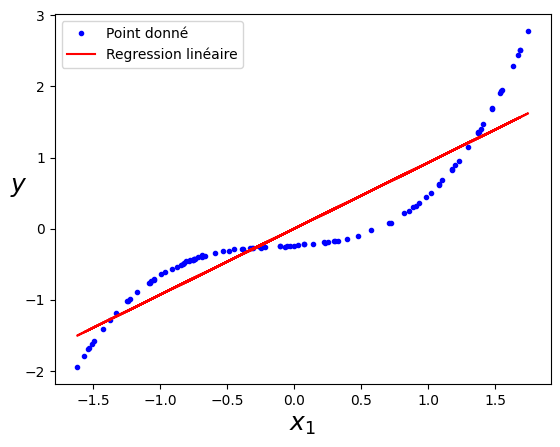

In [18]:
poly_reg = LinearRegression()
poly_reg.fit(X_poly, y_scaled)

point_donné = plt.plot(X_scaled, y_scaled, 'b.')
regression_lineaire = plt.plot(X_scaled, lin_reg.predict(X_scaled), 'r-')

# regression_polynomial = plt.plot(X_scaled, poly_reg.predict(X_poly), 'g-')

point_donné[0].set_label("Point donné")
regression_lineaire[0].set_label("Regression linéaire")

# regression_polynomial[0].set_label("Regression polynomial")

plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.legend()
plt.show()

/tmp/ipykernel_6588/786161492.py:2: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b." (-> color='b'). The keyword argument will take precedence.
  plt.plot(X, y, 'b.', label="Données originales", c="red") # Plot original data points
/tmp/ipykernel_6588/786161492.py:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-" (-> color='g'). The keyword argument will take precedence.
  plt.plot(X_new, y_new, 'g-', linewidth=2, label="Prédictions Polynomiales", alpha=0.75, c='blue') # Plot predictions against original X_new


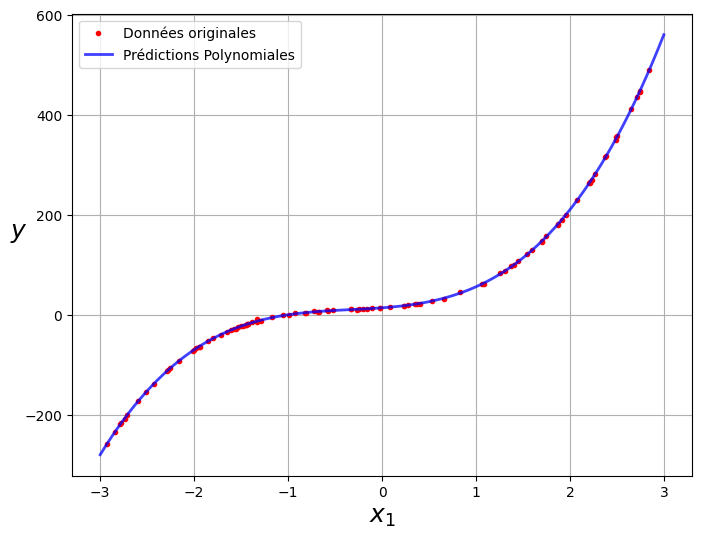

In [28]:
plt.figure(figsize=(8, 6))
plt.plot(X, y, 'b.', label="Données originales", c="red") # Plot original data points
plt.plot(X_new, y_new, 'g-', linewidth=2, label="Prédictions Polynomiales", alpha=0.75, c='blue') # Plot predictions against original X_new
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.legend()
plt.grid(True)
plt.show()

### 3ème Graphique : Régression Polynomiale avec Bruit Accru

Ce graphique montre l'effet d'un bruit supplémentaire sur les données et comment la régression polynomiale s'adapte à ces nouvelles données plus bruitées.

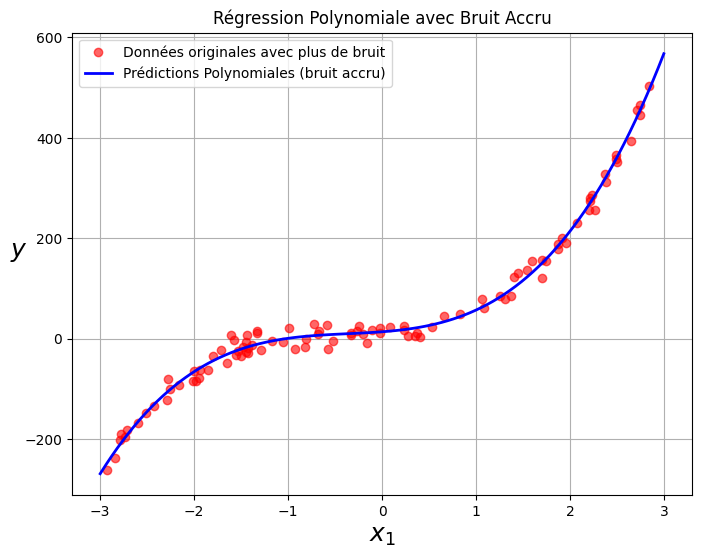

In [27]:
# Ajoutons plus de bruit à nos données originales 'y'
y_very_noisy = y + np.random.randn(m, 1) * 15 # Multiplier le bruit pour un effet plus prononcé

# Entraîner un nouveau modèle de régression polynomiale avec les données très bruitées
lin_regs_very_noisy = LinearRegression()
lin_regs_very_noisy.fit(X_poly, y_very_noisy)

# Générer les prédictions pour la nouvelle courbe
y_very_noisy_pred = lin_regs_very_noisy.predict(X_new_poly)

# Tracer le troisième graphique
plt.figure(figsize=(8, 6))
plt.plot(X, y_very_noisy, 'o', alpha=0.6, label="Données originales avec plus de bruit", color="red")
plt.plot(X_new, y_very_noisy_pred, '-', linewidth=2, label="Prédictions Polynomiales (bruit accru)", color="blue")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.title("Régression Polynomiale avec Bruit Accru")
plt.legend()
plt.grid(True)
plt.show()